Sources: 360 cities | Targets: 165 cities
Distance range: 31.0 ~ 6163.3 km

📁 Target city sensitivity results saved
  target_city  inflow_base       CV  rel_dev_mean
      Shihezi   237.730328 0.167237      0.015540
       Xining    25.882975 0.148481      0.019000
         Yili   382.405266 0.128215      0.008842
      Lanzhou   535.121074 0.124032      0.012279
    Panzhihua   224.400618 0.122539      0.009783
Xishuangbanna    79.420762 0.122380      0.011593
     Kelamayi   168.696571 0.112645      0.005298
 Shuangyashan   111.279553 0.107256      0.010245
         Yuxi   637.928719 0.105277      0.005383
     Yinchuan   456.118610 0.094722      0.008846

📊 Figure saved (Nature style):
   /Users/shirley/Desktop/plots_V2/cross_flow/sensitivity/sensitivity_analysis_2060.png


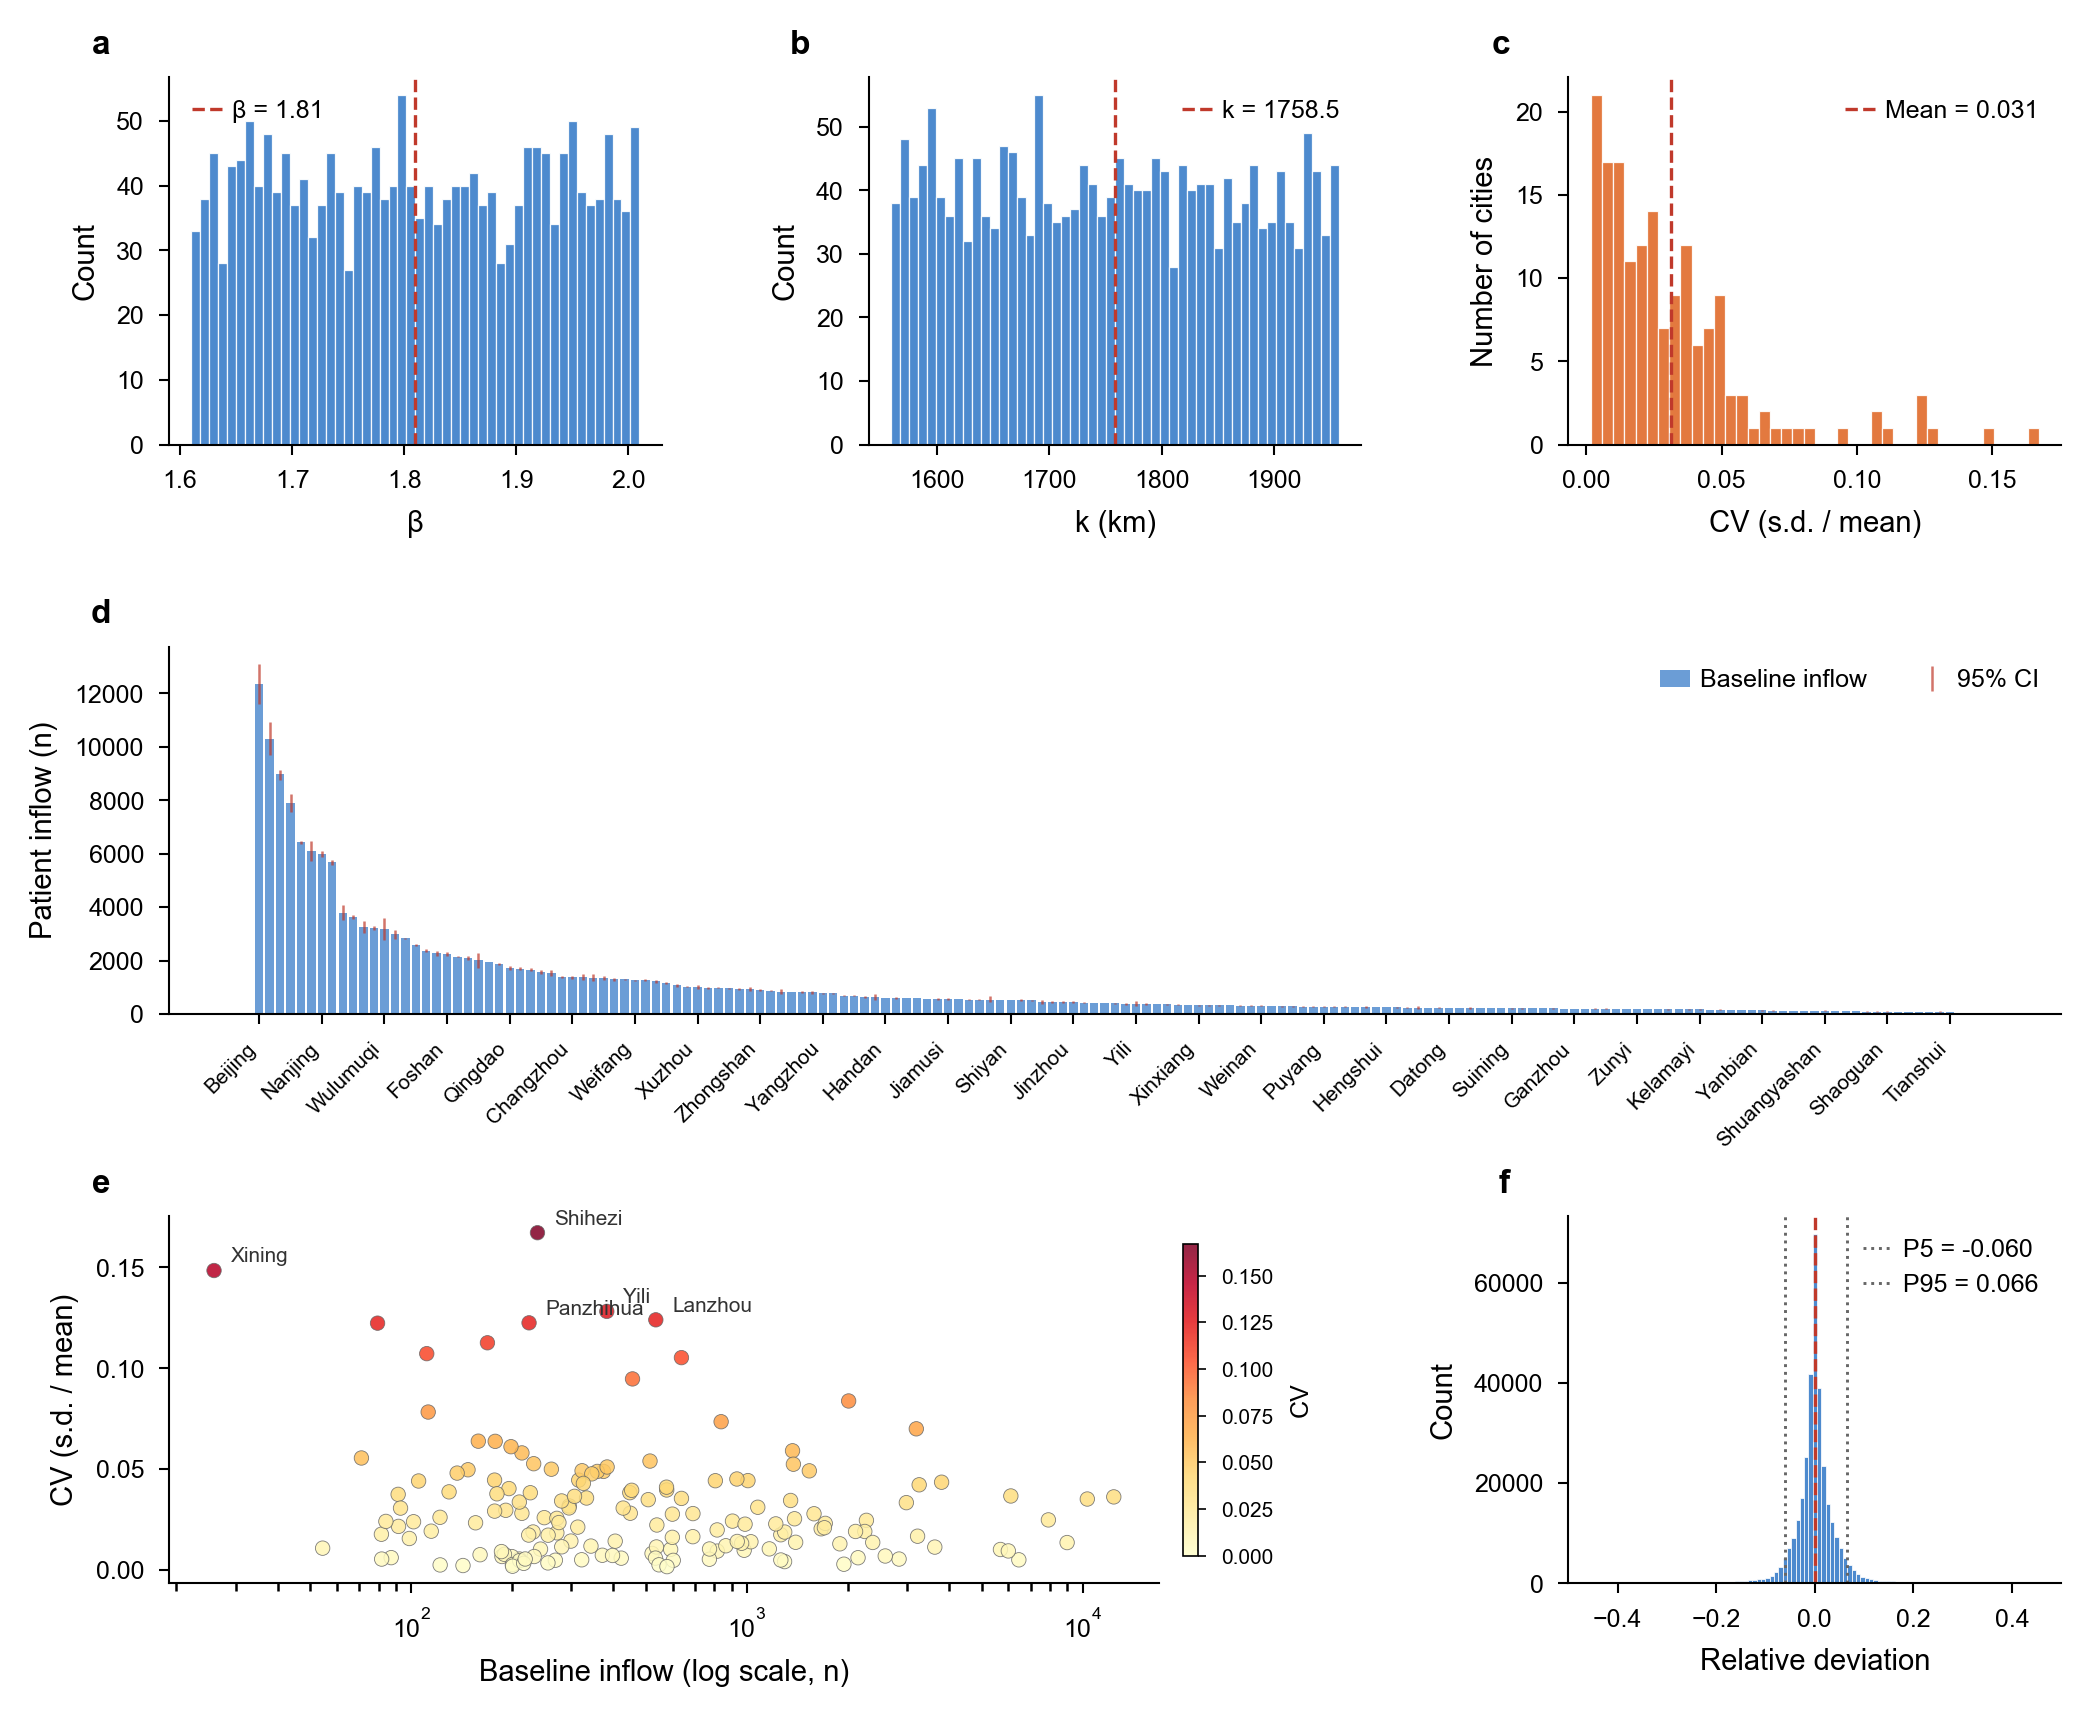

In [ ]:
# ===== Sensitivity Analysis: How BETA & KPAR affect F_ij =====
# Structure: A_ij = G_ij * S_j * K_ij  →  P_ij (row-norm)  →  F_ij = P_ij * C_i
#
# Key insight: row-normalisation means proportional K shifts cancel out.
# Sensitivity is driven by *relative* kernel differences across distances.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os


DIST_FILE = "/rail_distance_matrix.csv"   # raw distance matrix (km)
S_FILE    = "/city_medical_resources.xlsx"
S_COL     = "hospital_resource_value"
OUT_DIR   = "/cross_flow/sensitivity"
os.makedirs(OUT_DIR, exist_ok=True)

FIXED_AIR  = "ref"
FIXED_FER  = "mid"
FIXED_RCP  = "RCP4_5"
FIXED_YEAR = 2060     ## change to 2020,2030,etc.
FIXED_SCENARIO = "earlypeak_NZ_CL"

G_FILE = f"/gdp_matrix/city_pop_weighted_gdp_{FIXED_YEAR}_{FIXED_FER}_{FIXED_RCP}_reject_matrix.csv"
V_FILE = f"/city_patient_sum/citysum_{FIXED_SCENARIO}_{FIXED_YEAR}.csv"

# ===== Kernel parameters =====
BETA_BASE  = 1.81
KPAR_BASE  = 1758.5
R_MIN      = 150.0           # piecewise threshold (km)
 
# Sensitivity ranges
BETA_RANGE = 0.20            # ± range for uniform sampling
KPAR_RANGE = 200.0
N_SIM      = 2000            # number of MC draws
RANDOM_SEED = 42
 
 
# ===== Helper: piecewise kernel =====
def compute_kernel(D_arr, beta, kpar, r_min=150.0):
    K_boundary   = r_min ** (-beta) * np.exp(-r_min / kpar)
    lambda_short = beta / r_min + 1.0 / kpar
    K = np.full_like(D_arr, np.nan)
    tail  = D_arr >= r_min
    short = (D_arr < r_min) & ~np.isnan(D_arr)
    K[tail]  = D_arr[tail] ** (-beta) * np.exp(-D_arr[tail] / kpar)
    K[short] = K_boundary * np.exp(-lambda_short * (D_arr[short] - r_min))
    return K
 
 
# ===== Helper: read S =====
def read_S(xlsx_path, value_col):
    xls = pd.ExcelFile(xlsx_path)
    for sh in xls.sheet_names:
        df = pd.read_excel(xlsx_path, sheet_name=sh)
        df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]
        if "city" in df.columns and value_col in df.columns:
            out = df[["city", value_col]].copy()
            out["city"] = out["city"].astype(str).str.strip()
            return out.set_index("city")[value_col].astype(float)
    raise ValueError("Columns not found")
 
 
# ===== Load fixed data =====
D_raw = pd.read_csv(DIST_FILE, index_col=0).astype(float)
np.fill_diagonal(D_raw.values, np.nan)
 
S_full = read_S(S_FILE, S_COL)
G_full = pd.read_csv(G_FILE, index_col=0)
 
Vdf = pd.read_csv(V_FILE)
city_col = "city" if "city" in Vdf.columns else Vdf.columns[0]
Vdf[city_col] = Vdf[city_col].astype(str).str.strip()
Vdf = Vdf.set_index(city_col)

sources = [c for c in Vdf.index if c in G_full.index and c in D_raw.index]
targets = [c for c in S_full.index if c in G_full.columns and c in D_raw.columns]
 
G  = G_full.loc[sources, targets].values
D_km = D_raw.loc[sources, targets].values    
S_vec = S_full.reindex(targets).values
C_vec = Vdf["cross_patient_total"].astype(float).reindex(sources).values
 
print(f"Sources: {len(sources)} cities | Targets: {len(targets)} cities")
print(f"Distance range: {np.nanmin(D_km):.1f} ~ {np.nanmax(D_km):.1f} km")
 
 
# ===== Core function: compute F given kernel params =====
def compute_F(beta, kpar):
    K = compute_kernel(D_km, beta, kpar, R_MIN)
    A = G * S_vec[None, :] * K
    row_sum = np.nansum(A, axis=1)
    row_sum[row_sum == 0] = np.nan
    P = A / row_sum[:, None]
    P = np.nan_to_num(P, nan=0.0)
    F = P * C_vec[:, None]
    return F, P
 
 
# ===== Baseline =====
F_base, P_base = compute_F(BETA_BASE, KPAR_BASE)
F_base_df = pd.DataFrame(F_base, index=sources, columns=targets)
inflow_base = F_base_df.sum(axis=0)   # total inflow per target city
 
 
# ===== Monte Carlo =====
rng = np.random.default_rng(RANDOM_SEED)
beta_samples = rng.uniform(BETA_BASE - BETA_RANGE, BETA_BASE + BETA_RANGE, N_SIM)
kpar_samples = rng.uniform(KPAR_BASE - KPAR_RANGE, KPAR_BASE + KPAR_RANGE, N_SIM)
 

inflow_sims = np.zeros((N_SIM, len(targets)))
F_sims      = np.zeros((N_SIM, len(sources), len(targets)), dtype=np.float32)
 
for i in range(N_SIM):
    F_i, _ = compute_F(beta_samples[i], kpar_samples[i])
    F_sims[i]      = F_i
    inflow_sims[i] = F_i.sum(axis=0)
 
# ===== Statistics at target-city level (most policy-relevant) =====
inflow_mean = inflow_sims.mean(axis=0)
inflow_std  = inflow_sims.std(axis=0)
inflow_p025 = np.percentile(inflow_sims, 2.5,  axis=0)
inflow_p975 = np.percentile(inflow_sims, 97.5, axis=0)
inflow_cv   = inflow_std / (inflow_mean + 1e-8)
 
# Relative deviation from baseline
rel_dev_inflow = (inflow_sims - inflow_base.values[None, :]) / (inflow_base.values[None, :] + 1e-8)
 
# ===== Statistics at city-pair level =====
F_mean = F_sims.mean(axis=0)
F_cv   = F_sims.std(axis=0) / (F_mean + 1e-8)
 
# ===== Save results =====
target_summary = pd.DataFrame({
    "target_city":   targets,
    "inflow_base":   inflow_base.values,
    "inflow_mean":   inflow_mean,
    "inflow_std":    inflow_std,
    "inflow_p025":   inflow_p025,
    "inflow_p975":   inflow_p975,
    "CV":            inflow_cv,
    "rel_dev_mean":  rel_dev_inflow.mean(axis=0),
    "rel_dev_p95":   np.percentile(np.abs(rel_dev_inflow), 95, axis=0),
})
target_summary = target_summary.sort_values("CV", ascending=False)
target_summary.to_csv(os.path.join(OUT_DIR, "sensitivity_target_city_2060.csv"), index=False)
print(target_summary[["target_city","inflow_base","CV","rel_dev_mean"]].head(10).to_string(index=False))
 
 
# ===== Visualisation =====

plt.rcParams.update({
    "font.family":        "Arial",         
    "font.size":          7,               
    "axes.labelsize":     7,
    "axes.titlesize":     8,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "axes.linewidth":     0.5,           
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,            
    "axes.spines.right":  False,            
    "legend.frameon":     False,          
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "pdf.fonttype":       42,              
    "ps.fonttype":        42,
})
 

C_BLUE   = "#3A7DC9"    
C_ORANGE = "#E06B2A"    
C_GREY   = "#666666"    
C_RED    = "#C0392B"   
 

FIG_W = 18 / 2.54   
FIG_H = 15 / 2.54 
 
fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.55, wspace=0.42,
    left=0.08, right=0.97, top=0.95, bottom=0.10,
)
 
def panel_label(ax, letter, dx_pt=-14, dy_pt=4):
    """
    dx_pt : horizontal offset left of the axes (points, negative = left)
    dy_pt : vertical offset above the axes (points, positive = above)
    """
    ax.text(
        0, 1,                      
        letter,
        transform=ax.transAxes +
                  plt.matplotlib.transforms.ScaledTranslation(
                      dx_pt / 72, dy_pt / 72,
                      fig.dpi_scale_trans          
                  ),
        fontsize=8, fontweight="bold",
        va="bottom", ha="right",
    )
 
# ---- Panel a: BETA sampling distribution ----
ax = fig.add_subplot(gs[0, 0])
ax.hist(beta_samples, bins=50, color=C_BLUE, edgecolor="white",
        linewidth=0.3, alpha=0.9)
ax.axvline(BETA_BASE, color=C_RED, lw=0.8, linestyle="--",
           label=f"β = {BETA_BASE}")
ax.set_xlabel("β")
ax.set_ylabel("Count")
ax.legend(handlelength=1.2, handletextpad=0.4)
panel_label(ax, "a")
 
# ---- Panel b: KPAR sampling distribution ----
ax = fig.add_subplot(gs[0, 1])
ax.hist(kpar_samples, bins=50, color=C_BLUE, edgecolor="white",
        linewidth=0.3, alpha=0.9)
ax.axvline(KPAR_BASE, color=C_RED, lw=0.8, linestyle="--",
           label=f"k = {KPAR_BASE}")
ax.set_xlabel("k (km)")
ax.set_ylabel("Count")
ax.legend(handlelength=1.2, handletextpad=0.4)
panel_label(ax, "b")
 
# ---- Panel c: CV distribution across target cities ----
ax = fig.add_subplot(gs[0, 2])
ax.hist(inflow_cv, bins=40, color=C_ORANGE, edgecolor="white",
        linewidth=0.3, alpha=0.9)
ax.axvline(inflow_cv.mean(), color=C_RED, lw=0.8, linestyle="--",
           label=f"Mean = {inflow_cv.mean():.3f}")
ax.set_xlabel("CV (s.d. / mean)")
ax.set_ylabel("Number of cities")
ax.legend(handlelength=1.2, handletextpad=0.4)
panel_label(ax, "c")
 
# ---- Panel d: Inflow per target city with 95% CI ----
ax = fig.add_subplot(gs[1, :])
sort_idx       = np.argsort(inflow_base.values)[::-1]
x              = np.arange(len(targets))
sorted_targets = [targets[i] for i in sort_idx]
 
ax.bar(x, inflow_base.values[sort_idx],
       color=C_BLUE, alpha=0.75, width=0.8, linewidth=0,
       label="Baseline inflow")
ax.errorbar(
    x, inflow_mean[sort_idx],
    yerr=[inflow_mean[sort_idx] - inflow_p025[sort_idx],
          inflow_p975[sort_idx] - inflow_mean[sort_idx]],
    fmt="none", color=C_RED, alpha=0.7,
    linewidth=0.6, capsize=0,
    label="95% CI",
)
step = max(1, len(targets) // 25)
ax.set_xticks(x[::step])
ax.set_xticklabels(
    [sorted_targets[i] for i in range(0, len(targets), step)],
    rotation=45, ha="right", fontsize=5,
)
ax.set_ylabel("Patient inflow (n)")
ax.legend(handlelength=1.2, handletextpad=0.4,
          ncol=2, loc="upper right")
panel_label(ax, "d")
 
# ---- Panel e: Sensitivity map — CV vs baseline inflow ----
ax = fig.add_subplot(gs[2, 0:2])
sc = ax.scatter(
    inflow_base.values, inflow_cv,
    c=inflow_cv, cmap="YlOrRd",
    s=12, alpha=0.85, linewidths=0.2, edgecolors=C_GREY,
    vmin=0, vmax=inflow_cv.max(),
)
cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label("CV", fontsize=6)
cbar.ax.tick_params(labelsize=5, width=0.4, length=2)
cbar.outline.set_linewidth(0.4)
 
# annotate top-5 CV cities
top5 = np.argsort(inflow_cv)[-5:]
for idx in top5:
    ax.annotate(
        targets[idx],
        (inflow_base.values[idx], inflow_cv[idx]),
        fontsize=5, color="#333333",
        xytext=(4, 2), textcoords="offset points",
    )
ax.set_xscale("log")
ax.set_xlabel("Baseline inflow (log scale, n)")
ax.set_ylabel("CV (s.d. / mean)")
panel_label(ax, "e")
 
# ---- Panel f: Relative deviation distribution ----
ax = fig.add_subplot(gs[2, 2])
ax.hist(rel_dev_inflow.flatten(), bins=80,
        color=C_BLUE, edgecolor="white", linewidth=0.2, alpha=0.9)
ax.axvline(0, color=C_RED, lw=0.8, linestyle="--")
p5, p95 = np.percentile(rel_dev_inflow.flatten(), [5, 95])
ax.axvline(p5,  color=C_GREY, lw=0.7, linestyle=":",
           label=f"P5 = {p5:.3f}")
ax.axvline(p95, color=C_GREY, lw=0.7, linestyle=":",
           label=f"P95 = {p95:.3f}")
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel("Relative deviation")
ax.set_ylabel("Count")
ax.legend(handlelength=1.2, handletextpad=0.4)
panel_label(ax, "f")
 
plt.savefig(
    os.path.join(OUT_DIR, "sensitivity_analysis_2060.png"),
    bbox_inches="tight", dpi=300,
)
print(f"\n📊 Figure saved (Nature style):\n"
      f"   {OUT_DIR}/sensitivity_analysis_2060.png")
plt.show()
 